In [49]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [50]:
from src.utils.nb_run_logger import NBRunLogger
from pathlib import Path

NOTEBOOK_PATH = Path(r"./NOMBRE_DE_ESTE_NOTEBOOK.ipynb")  # <-- ajusta

seed = 0
run_logger = NBRunLogger("barrier", "Classical", seed=seed, tag="pinn_2-64-64-64-64-2_v3f_e1.5k")  # <-- cambia box/DV según notebook

# Guardado automático de figuras aunque NO haya plt.show()
run_logger.enable_autosave_figures_each_cell()

print("RUN_DIR:", run_logger.run_dir.resolve())
print("FIG_DIR:", run_logger.fig_dir.resolve())
print("ART_DIR:", run_logger.art_dir.resolve())

RUN_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\barrier\Classical\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k
FIG_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\barrier\Classical\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k\figures
ART_DIR: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\barrier\Classical\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k\artifacts


In [51]:
# ===================== FIGURES UTILS (PEGABLE EN TODOS LOS NOTEBOOKS) =====================
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

def _infer_fig_dir(logger=None, default="./results/figures"):
    """
    Intenta usar una carpeta asociada al logger si existe; si no, usa default.
    Siempre crea una subcarpeta 'figures'.
    """
    base = None
    if logger is not None:
        # prueba atributos típicos
        for attr in ["run_dir", "log_dir", "save_dir", "out_dir", "root_dir", "base_dir", "exp_dir"]:
            if hasattr(logger, attr):
                base = Path(getattr(logger, attr))
                break
    if base is None:
        base = Path(default)

    fig_dir = base if base.name == "figures" else (base / "figures")
    fig_dir.mkdir(parents=True, exist_ok=True)
    return fig_dir

def plot_loss_l2(model, fig_dir, l2_every=1, tag=""):
    loss_hist = np.asarray(getattr(model, "loss_history", []), dtype=float)
    l2_hist   = np.asarray(getattr(model, "l2_rel_history", []), dtype=float)

    fig = plt.figure(figsize=(12,4))

    ax1 = plt.subplot(1,2,1)
    ax1.plot(np.arange(len(loss_hist)), loss_hist)
    ax1.set_yscale("log")
    ax1.set_title("Loss vs epochs")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss")

    ax2 = plt.subplot(1,2,2)
    x_l2 = np.arange(len(l2_hist)) * max(int(l2_every), 1)  # respeta l2_every del trainer
    ax2.plot(x_l2, l2_hist)
    ax2.set_yscale("log")
    ax2.set_title("L2 relative error vs epochs")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("L2 rel")

    plt.tight_layout()

    fname = f"loss_l2{tag}.png" if tag else "loss_l2.png"
    fig.savefig(Path(fig_dir)/fname, dpi=200, bbox_inches="tight")
    plt.show()

def plot_prob_slices(model, problem, fig_dir, Nx=500, tag=""):
    """
    |psi(x,0)|^2 y |psi(x,T)|^2 (exact vs pred)
    """
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)
    t0 = torch.zeros_like(x)
    tT = torch.full_like(x, float(problem["T"]))

    exact_fn = problem.get("exact", None)
    n_level  = problem.get("n_level", 0)

    with torch.no_grad():
        y0 = model(torch.cat([t0, x], dim=1))
        yT = model(torch.cat([tT, x], dim=1))
        re0_pr, im0_pr = y0[:,0:1], y0[:,1:2]
        reT_pr, imT_pr = yT[:,0:1], yT[:,1:2]

        if callable(exact_fn):
            re0_ex, im0_ex, _ = exact_fn(n_level, t0, x)
            reT_ex, imT_ex, _ = exact_fn(n_level, tT, x)
        else:
            re0_ex = im0_ex = reT_ex = imT_ex = None

    p0_pr = (re0_pr**2 + im0_pr**2).detach().cpu().numpy().squeeze()
    pT_pr = (reT_pr**2 + imT_pr**2).detach().cpu().numpy().squeeze()
    xx    = x.detach().cpu().numpy().squeeze()

    fig = plt.figure(figsize=(10,4))

    ax1 = plt.subplot(1,2,1)
    if re0_ex is not None:
        p0_ex = (re0_ex**2 + im0_ex**2).detach().cpu().numpy().squeeze()
        ax1.plot(xx, p0_ex, label="Exact")
    ax1.plot(xx, p0_pr, "--", label="Pred")
    ax1.set_title(r"$|\psi(x,0)|^2$")
    ax1.set_xlabel("x"); ax1.set_ylabel(r"$|\psi|^2$")
    ax1.legend()

    ax2 = plt.subplot(1,2,2)
    if re0_ex is not None:
        pT_ex = (reT_ex**2 + imT_ex**2).detach().cpu().numpy().squeeze()
        ax2.plot(xx, pT_ex, label="Exact")
    ax2.plot(xx, pT_pr, "--", label="Pred")
    ax2.set_title(rf"$|\psi(x,T)|^2$  (T={float(problem['T'])})")
    ax2.set_xlabel("x"); ax2.set_ylabel(r"$|\psi|^2$")
    ax2.legend()

    plt.tight_layout()

    fname = f"prob_slices{tag}.png" if tag else "prob_slices.png"
    fig.savefig(Path(fig_dir)/fname, dpi=200, bbox_inches="tight")
    plt.show()

def plot_re_im_maps(model, problem, fig_dir, Nt=80, Nx=220, tag=""):
    """
    Mapas tipo imshow:
    Re exact/pred, Im exact/pred, y errores.
    Si no hay exact(), grafica solo pred.
    """
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
    x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

    TT = t_grid.repeat(1, Nx).reshape(-1,1)
    XX = x_grid.repeat(Nt, 1)

    exact_fn = problem.get("exact", None)
    n_level  = problem.get("n_level", 0)

    with torch.no_grad():
        y_pr = model(torch.cat([TT, XX], dim=1))
        re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

        has_exact = callable(exact_fn)
        if has_exact:
            re_ex, im_ex, _ = exact_fn(n_level, TT, XX)
        else:
            re_ex = im_ex = None

    re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
    im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

    extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

    if has_exact:
        re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
        im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
        re_er = re_pr - re_ex
        im_er = im_pr - im_ex

        fig = plt.figure(figsize=(12,8))
        plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
        plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

        plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
        plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

        plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
        plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()
        plt.tight_layout()

        fname = f"reim_maps{tag}.png" if tag else "reim_maps.png"
        fig.savefig(Path(fig_dir)/fname, dpi=200, bbox_inches="tight")
        plt.show()
    else:
        # sin exact: solo pred (útil si algún caso no trae referencia)
        fig = plt.figure(figsize=(12,4))
        plt.subplot(1,2,1); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred"); plt.ylabel("t"); plt.colorbar()
        plt.subplot(1,2,2); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred"); plt.colorbar()
        plt.tight_layout()

        fname = f"reim_pred_only{tag}.png" if tag else "reim_pred_only.png"
        fig.savefig(Path(fig_dir)/fname, dpi=200, bbox_inches="tight")
        plt.show()

In [52]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float64"   # usa float64 para Schrödinger (más estable)

print("device:", device, "| dtype:", dtype)



device: cpu | dtype: float64


In [53]:
import importlib

import src.trainer.schrodinger_train as sch_train
import src.nn.ClassicalSolver2 as cs2

importlib.reload(sch_train)
importlib.reload(cs2)

from src.trainer.schrodinger_train import train
from src.nn.ClassicalSolver2 import ClassicalSolver2

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem
from src.utils.logger import Logging


In [54]:
eq_params = build_eq_params(
    "barrier",
    L=1.0,
    T=0.2,
    mass=1.0,
    hbar=1.0,
    n_level=1,
    V0=3.0,
    barrier_width=0.2,
    x_center=0.6,
    num_grid=800,
)

print("eq_params:", eq_params)
print("sanity:", sanity_check(eq_params, device=device))



eq_params: {'example': 'barrier', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 3.0, 'barrier_width': 0.2, 'x_center': 0.6, 'num_grid': 800}
sanity: {'V_min': 0.0, 'V_max': 3.0, 'psi0_norm': 0.9974916267584284, 'psiT_norm': 0.9974916267584284}


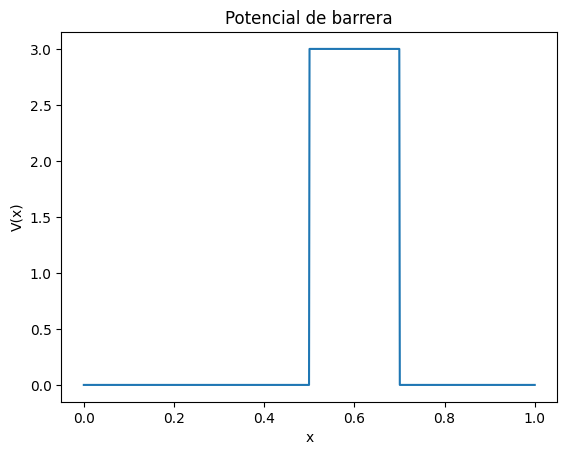

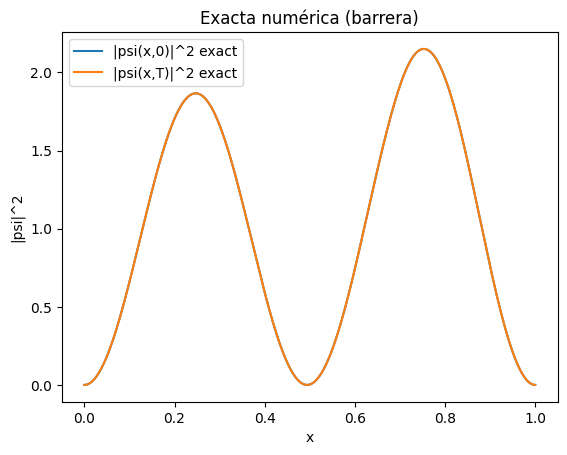

In [55]:
pb = build_problem(eq_params, device=torch.device(device),
                   dtype=torch.float64 if "64" in dtype else torch.float32)

x = torch.linspace(pb["x_min"], pb["x_max"], 900, device=device, dtype=pb["dtype"]).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    V = pb["potential_fn"](t0, x)
    r0,i0,_ = pb["exact"](pb["n_level"], t0, x)
    rT,iT,_ = pb["exact"](pb["n_level"], tT, x)

x_cpu = x.detach().cpu().numpy().flatten()
V_cpu = V.detach().cpu().numpy().flatten()
p0_cpu = (r0**2 + i0**2).detach().cpu().numpy().flatten()
pT_cpu = (rT**2 + iT**2).detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, V_cpu)
plt.xlabel("x"); plt.ylabel("V(x)")
plt.title("Potencial de barrera")
plt.show()

plt.figure()
plt.plot(x_cpu, p0_cpu, label="|psi(x,0)|^2 exact")
plt.plot(x_cpu, pT_cpu, label="|psi(x,T)|^2 exact")
plt.legend()
plt.xlabel("x"); plt.ylabel("|psi|^2")
plt.title("Exacta numérica (barrera)")
plt.show()



In [56]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,

    "epochs": 1500,
    "lr": 1e-3,
    "batch_size": 64,
    "classic_network": [2, 64, 64, 64, 64, 2],
    "print_every": 20,

    # Barrera: BC dura
    "hard_bc": True,
    "w_bc": 0.0,

    # pesos
    "w_pde": 1.0,
    "w_ic": 300.0,
    "w_norm": 50.0,

    # estabilidad
    "ic_grid": True,
    "warmup_epochs": 300,

    # focus sampling (trainer nuevo)
    "focus_frac": 0.45,
    "focus_margin_frac": 0.30,

    # LBFGS al final (muy útil en barrera)
    "use_lbfgs": False,
    "lbfgs_max_iter": 500,
    "lbfgs_lr": 1.0,

    # opcional (si ves explosiones)
    # "grad_clip": 1.0,
}

from pathlib import Path
ckpt_dir = Path(run_logger.run_dir) / "checkpoints"
logger = Logging(str(ckpt_dir), f"barrier_Classical_seed{seed}")
model = ClassicalSolver2(args, logger, device=torch.device(device))
model.args = args

# chequeo forward
param_dtype = next(model.parameters()).dtype
t_test = torch.rand(8, 1, device=device, dtype=param_dtype) * eq_params["T"]
x_test = torch.rand(8, 1, device=device, dtype=param_dtype) * (eq_params["x_max"] - eq_params["x_min"]) + eq_params["x_min"]
y = model(torch.cat([t_test, x_test], dim=1))
print("forward ok ->", y.shape, y.dtype, y.device)



INFO:src.utils.logger:checkpoint path: self.log_path='results\\barrier\\Classical\\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k\\checkpoints\\2026-02-26_09-11-08-037447_barrier_Classical_seed0'
forward ok -> torch.Size([8, 2]) torch.float64 cpu


In [57]:
run_logger.log_config(eq_params=eq_params, args=args)
pc = run_logger.log_param_count(model)
print("Trainable params:", pc)

import logging, sys
from pathlib import Path

def force_live_logging(log_file: Path, level=logging.INFO):
    log_file.parent.mkdir(parents=True, exist_ok=True)
    logging.disable(logging.NOTSET)

    logging.basicConfig(
        level=level,
        format="%(levelname)s:%(name)s:%(message)s",
        handlers=[
            logging.StreamHandler(sys.stdout),
            logging.FileHandler(log_file, encoding="utf-8"),
        ],
        force=True,
    )

    for name in ["src.utils.logger", "src.trainer.schrodinger_train"]:
        lg = logging.getLogger(name)
        lg.setLevel(level)
        lg.propagate = True
        lg.disabled = False

    sys.stdout.flush()

force_live_logging(run_logger.art_dir / "python.log")

import logging
lg = logging.getLogger("src.utils.logger")
lg.handlers.clear()
lg.propagate = True
lg.disabled = False
lg.setLevel(logging.INFO)


Trainable params: {'total': 12802, 'quantum': 0, 'classical': 12802}


In [58]:
train(model, N_f=512, N_b=0, N_0=1000)





INFO:src.utils.logger:It: 1, Loss: 3.473e+02, Loss_res: 1.338e-02,  Loss_bcs: 0.000e+00, Loss_ut_ics: 9.910e-01, Loss_norm: 9.998e-01, Loss_gauge: 0.000e+00, w_pde: 3.33e-03, L^2_error: 1.010e+00, lr: 1.000e-03, Time: 3.45e-01
INFO:src.utils.logger:Model state saved to results\barrier\Classical\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k\checkpoints\2026-02-26_09-11-08-037447_barrier_Classical_seed0\model.pth
INFO:src.utils.logger:Model weights saved to results\barrier\Classical\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k\checkpoints\2026-02-26_09-11-08-037447_barrier_Classical_seed0\model_weights.pth
INFO:src.utils.logger:It: 20, Loss: 2.493e+02, Loss_res: 4.259e+01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 7.254e-01, Loss_norm: 5.758e-01, Loss_gauge: 0.000e+00, w_pde: 6.67e-02, L^2_error: 1.256e+00, lr: 1.000e-03, Time: 1.72e+00
INFO:src.utils.logger:Model state saved to results\barrier\Classical\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k\checkpoints\2026-02-26_

In [59]:
meta = run_logger.log_histories(model)
print("history_meta:", meta)

parsed = run_logger.parse_schrodinger_train_log()
print("Puntos parseados del log:", len(parsed["it"]))
print("Último it/loss/l2:", parsed["it"][-1], parsed["loss"][-1], parsed["l2"][-1])

history_meta: {'loss_history_len': 1500, 'l2_rel_history_len': 1500, 'loss_history_type': "<class 'list'>", 'l2_rel_history_type': "<class 'list'>"}
Puntos parseados del log: 76
Último it/loss/l2: 1500 3.225 0.3736


L2_rel(T): 0.37360925427349245


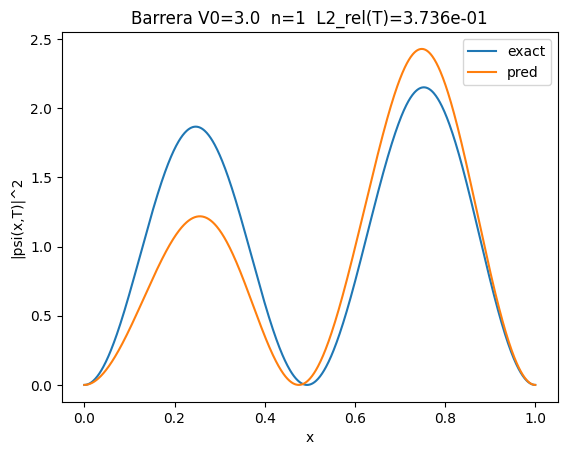

In [60]:
pb = build_problem(eq_params, device=torch.device(device),
                   dtype=torch.float64 if "64" in dtype else torch.float32)

x = torch.linspace(pb["x_min"], pb["x_max"], 900, device=device, dtype=pb["dtype"]).reshape(-1,1)
t = torch.full_like(x, pb["T"])

with torch.no_grad():
    pred = model(torch.cat([t, x], dim=1))
    pr, pi = pred[:,0:1], pred[:,1:2]
    er, ei, _ = pb["exact"](pb["n_level"], t, x)

    l2_abs = torch.sqrt(torch.mean((pr-er)**2 + (pi-ei)**2))
    ref = torch.sqrt(torch.mean(er**2 + ei**2)) + 1e-12
    l2_rel = (l2_abs/ref).item()

print("L2_rel(T):", l2_rel)

prob_pred  = (pr**2 + pi**2).detach().cpu().numpy().flatten()
prob_exact = (er**2 + ei**2).detach().cpu().numpy().flatten()
x_cpu      = x.detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, prob_exact, label="exact")
plt.plot(x_cpu, prob_pred,  label="pred")
plt.legend()
plt.xlabel("x"); plt.ylabel("|psi(x,T)|^2")
plt.title(f"Barrera V0={eq_params['V0']}  n={eq_params['n_level']}  L2_rel(T)={l2_rel:.3e}")
plt.show()


In [61]:
pb = build_problem(eq_params, device=torch.device(device), dtype=torch.float64)

x = torch.linspace(pb["x_min"], pb["x_max"], 1400, device=device, dtype=pb["dtype"]).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    p0 = model(torch.cat([t0, x], dim=1))
    pT = model(torch.cat([tT, x], dim=1))

    prob0 = p0[:,0]**2 + p0[:,1]**2
    probT = pT[:,0]**2 + pT[:,1]**2

    norm0 = torch.trapz(prob0, x.squeeze(-1)).item()
    normT = torch.trapz(probT, x.squeeze(-1)).item()

print("Norm pred t=0:", norm0)
print("Norm pred t=T:", normT)



Norm pred t=0: 0.9737179047277336
Norm pred t=T: 0.9182573859271597


Figuras en: results\figures


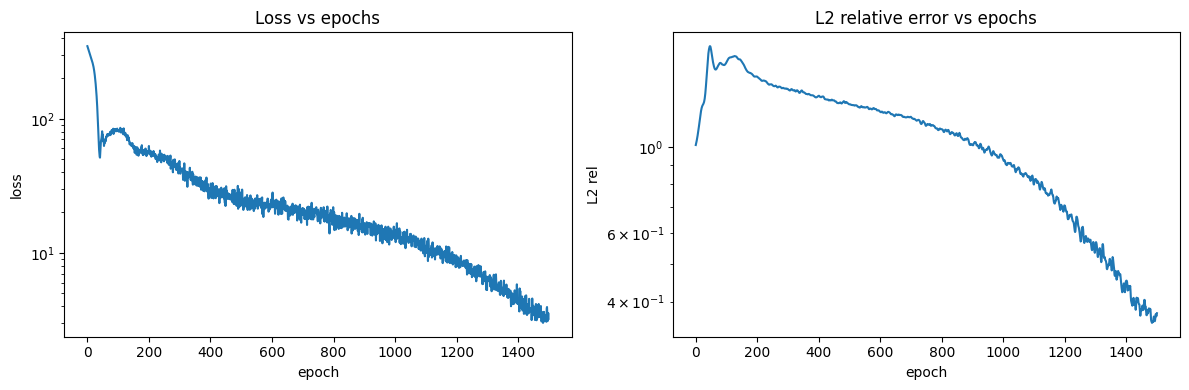

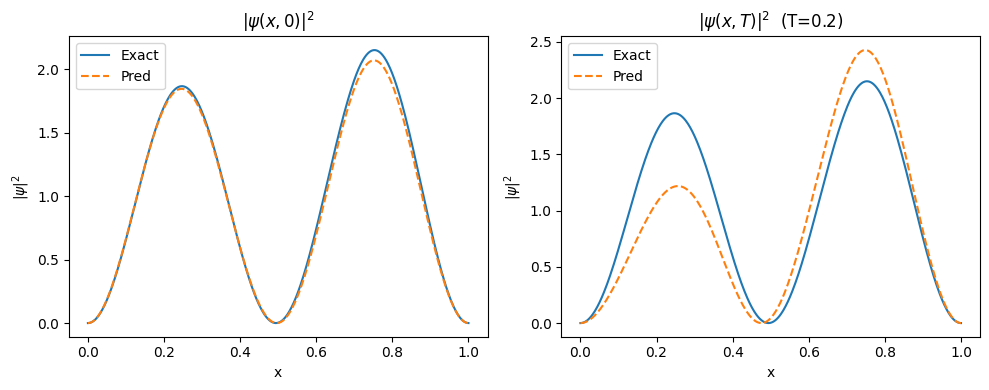

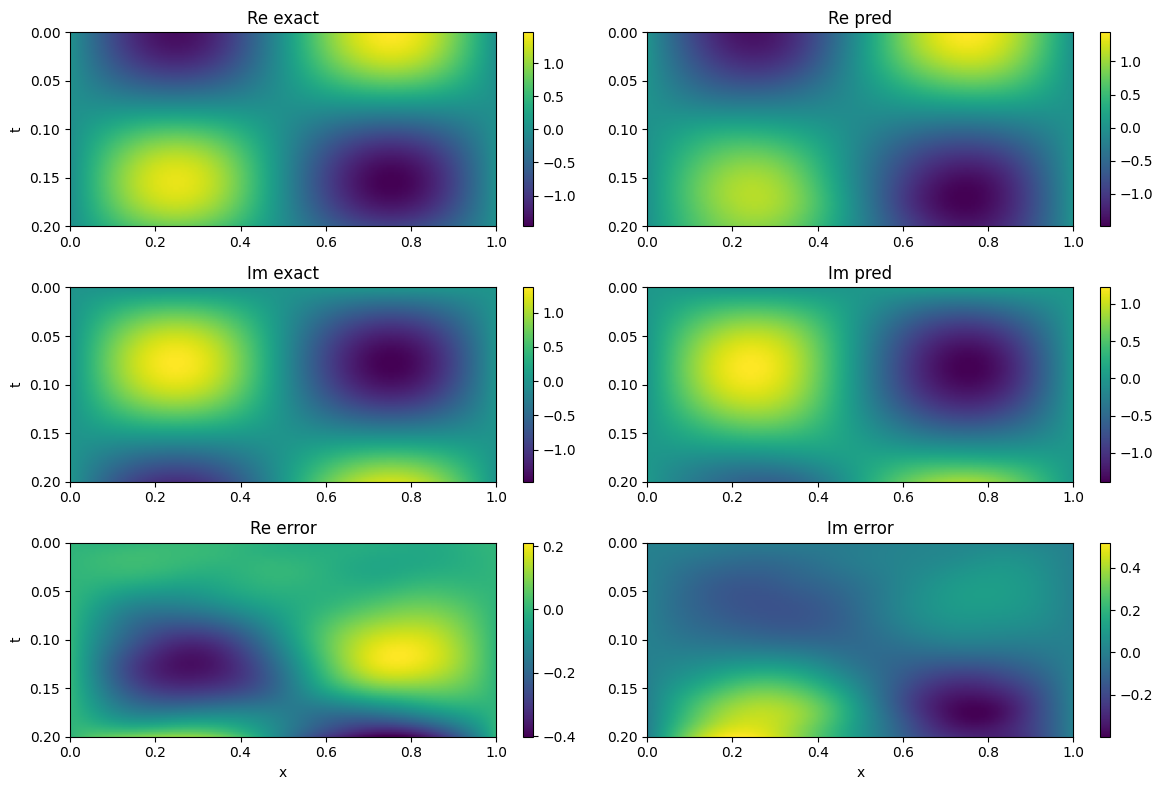

In [62]:
# ===================== POST-TRAIN: GENERAR FIGURAS (PEGABLE EN TODOS) =====================
from src.problems.schrodinger.problem import build_problem  # asegúrate de tener este import en el notebook

# 1) carpeta de figuras (usa logger si tiene run_dir; si no, cae en ./results/figures)
fig_dir = _infer_fig_dir(logger)
print("Figuras en:", fig_dir)

# 2) construir 'problem' consistente con eq_params (sirve para box/ho/barrera)
device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype
problem = build_problem(eq_params, device=device_, dtype=dtype_)

# (opcional) etiqueta para diferenciar etapas
tag = ""           # ejemplo: "_stage1" o "_stage2"
l2_every = model.args.get("l2_every", 1) if hasattr(model, "args") else 1

# 3) curvas y mapas
plot_loss_l2(model, fig_dir, l2_every=l2_every, tag=tag)
plot_prob_slices(model, problem, fig_dir, Nx=500, tag=tag)
plot_re_im_maps(model, problem, fig_dir, Nt=80, Nx=220, tag=tag)

In [63]:
run_logger.flush_figures()
print("Figuras guardadas:", len(list(run_logger.fig_dir.glob("*.png"))))

Figuras guardadas: 6


In [64]:
# ===================== (TESIS) MÉTRICAS MÍNIMAS + CSV GLOBAL REUTILIZABLE =====================
import json
import csv
from datetime import datetime
from pathlib import Path

import torch

# --- Requiere: model, eq_params, run_logger (y idealmente device/dtype/args si existen) ---
assert "model" in globals(), "No encuentro 'model'. Ejecuta esta celda después de entrenar."
assert "eq_params" in globals(), "No encuentro 'eq_params'."
assert "run_logger" in globals(), "No encuentro 'run_logger'."

# ---------- Utils ----------
def _to_path(x):
    try:
        return Path(x)
    except Exception:
        return Path(str(x))

def _safe_get(d, key, default=None):
    try:
        return d.get(key, default)
    except Exception:
        return default

def _write_json(path: Path, obj: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def _model_eval(model, t, x):
    """Soporta model([t,x]) o model(t,x) según tu API."""
    try:
        return model(torch.cat([t, x], dim=1))
    except Exception:
        return model(t, x)

def _l2_rel_prob(prob_pred: torch.Tensor, prob_exact: torch.Tensor, eps: float = 1e-12) -> float:
    num = torch.sqrt(torch.mean((prob_pred - prob_exact) ** 2))
    den = torch.sqrt(torch.mean(prob_exact ** 2)) + eps
    return (num / den).item()

def _find_results_root_from_run_logger(run_logger):
    """Intenta encontrar carpeta 'results' a partir de run_logger.run_dir; si no, usa ./results."""
    run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
    # caso 1: alguna carpeta padre se llama "results"
    for p in [run_dir] + list(run_dir.parents):
        if p.name.lower() == "results":
            return p
    # caso 2: algún padre contiene una carpeta llamada "results"
    for p in run_dir.parents:
        cand = p / "results"
        if cand.exists() and cand.is_dir():
            return cand
    # fallback
    return (Path(".") / "results").resolve()

def _append_or_update_csv(csv_path: Path, row: dict, key_col: str = "run_dir"):
    """
    Agrega una fila al CSV. Si ya existe una fila con el mismo key_col (p.ej. run_dir), la reemplaza.
    Funciona sin pandas (solo stdlib).
    """
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    rows = []
    cols = list(row.keys())

    if csv_path.exists():
        with open(csv_path, "r", newline="", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            old_cols = reader.fieldnames or []
            cols = list(dict.fromkeys(old_cols + cols))  # unión preservando orden
            for r in reader:
                rows.append(r)

        # filtra si ya existe esa corrida
        new_rows = []
        for r in rows:
            if r.get(key_col, "") != str(row.get(key_col, "")):
                new_rows.append(r)
        rows = new_rows

    # agrega la fila nueva
    # asegura todas las columnas
    row_filled = {c: row.get(c, "") for c in cols}
    rows.append(row_filled)

    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=cols)
        writer.writeheader()
        writer.writerows(rows)

# ---------- Construye pb / exact ----------
from src.problems.schrodinger.problem import build_problem

# dtype/device robusto
device_val = globals().get("device", "cpu")
dev = torch.device(device_val) if not isinstance(device_val, torch.device) else device_val

dtype_str = str(globals().get("dtype", _safe_get(getattr(model, "args", {}), "dtype", "float64")))
torch_dtype = torch.float64 if "64" in dtype_str else torch.float32

pb = build_problem(eq_params, device=dev, dtype=torch_dtype)

# eval grid
num_x = int(_safe_get(eq_params, "num_grid", 800))
x = torch.linspace(pb["x_min"], pb["x_max"], num_x, device=dev, dtype=pb["dtype"]).reshape(-1, 1)

T = float(pb["T"])
t_fracs = [0.0, 0.25, 0.50, 0.75, 1.0]
t_eval = torch.tensor([f * T for f in t_fracs], device=dev, dtype=pb["dtype"]).reshape(-1, 1)

# Detecta exacta
has_exact = ("exact" in pb) and callable(pb["exact"])

series = []
l2_rel_psi_T = None
l2_rel_prob_T = None

with torch.no_grad():
    for ti in t_eval:
        t = ti.repeat(x.shape[0], 1)
        pred = _model_eval(model, t, x)
        pr, pi = pred[:, 0:1], pred[:, 1:2]

        rec = {"t": float(ti.item())}

        if has_exact:
            er, ei, _ = pb["exact"](pb["n_level"], t, x)

            # L2 relativo de psi (Re+Im)
            l2_abs_psi = torch.sqrt(torch.mean((pr - er) ** 2 + (pi - ei) ** 2))
            ref_psi = torch.sqrt(torch.mean(er ** 2 + ei ** 2)) + 1e-12
            rec["l2_rel_psi"] = float((l2_abs_psi / ref_psi).item())

            # L2 relativo de |psi|^2
            prob_pred = pr ** 2 + pi ** 2
            prob_exact = er ** 2 + ei ** 2
            rec["l2_rel_prob"] = float(_l2_rel_prob(prob_pred, prob_exact))

        series.append(rec)

# extrae T
if has_exact and len(series) > 0:
    l2_rel_psi_T = series[-1].get("l2_rel_psi", None)
    l2_rel_prob_T = series[-1].get("l2_rel_prob", None)

# Boundary check (genérico: xmin/xmax)
ts = torch.linspace(0.0, T, 20, device=dev, dtype=pb["dtype"]).reshape(-1, 1)
x_min = torch.full_like(ts, float(pb["x_min"]))
x_max = torch.full_like(ts, float(pb["x_max"]))

with torch.no_grad():
    psi_min = _model_eval(model, ts, x_min)
    psi_max = _model_eval(model, ts, x_max)

bdry_xmin = torch.sqrt(psi_min[:, 0] ** 2 + psi_min[:, 1] ** 2).max().item()
bdry_xmax = torch.sqrt(psi_max[:, 0] ** 2 + psi_max[:, 1] ** 2).max().item()

# ---------- Metadata (reutilizable en todos) ----------
args = globals().get("args", getattr(model, "args", {})) or {}
potential = str(getattr(run_logger, "problem", _safe_get(eq_params, "potential", _safe_get(eq_params, "name", "unknown"))))
solver = str(getattr(run_logger, "solver", getattr(run_logger, "solver_type", _safe_get(args, "solver_type", "unknown"))))
seed = getattr(run_logger, "seed", _safe_get(args, "seed", None))
tag = getattr(run_logger, "tag", _safe_get(args, "tag", ""))

run_dir = _to_path(getattr(run_logger, "run_dir", ".")).resolve()
art_dir = _to_path(getattr(run_logger, "art_dir", run_dir / "artifacts")).resolve()

# parámetros entrenables (total)
n_params_total = int(sum(p.numel() for p in model.parameters() if p.requires_grad))

# si existe una función de conteo detallado (DV notebooks), úsala
n_params_quantum = ""
n_params_classical = ""
if "count_trainable_params" in globals() and callable(globals()["count_trainable_params"]):
    try:
        out = globals()["count_trainable_params"](model)
        if isinstance(out, dict):
            n_params_total = int(out.get("total", n_params_total))
            n_params_quantum = int(out.get("quantum", ""))
            n_params_classical = int(out.get("classical", ""))
        elif isinstance(out, (tuple, list)) and len(out) >= 3:
            n_params_total = int(out[0])
            n_params_quantum = int(out[1])
            n_params_classical = int(out[2])
    except Exception:
        pass

# identifica arquitectura / ansatz / encoding (sin forzar que existan)
classic_network = _safe_get(args, "classic_network", "")
num_qubits = _safe_get(args, "num_qubits", "")
num_layers = _safe_get(args, "num_quantum_layers", _safe_get(args, "num_layers", ""))
q_ansatz = _safe_get(args, "q_ansatz", "")
encoding = _safe_get(args, "encoding", "")

arch_repr = ""
if q_ansatz or num_qubits or num_layers:
    arch_repr = f"DV(q={num_qubits}, L={num_layers}, ansatz={q_ansatz}, enc={encoding}, classic={classic_network})"
else:
    arch_repr = f"PINN(classic={classic_network})"

# epochs/lr y puntos si están disponibles (si no, quedan vacíos)
epochs = _safe_get(args, "epochs", "")
lr = _safe_get(args, "lr", "")
N_f = globals().get("N_f", _safe_get(args, "N_f", ""))
N_b = globals().get("N_b", _safe_get(args, "N_b", ""))
N_0 = globals().get("N_0", _safe_get(args, "N_0", ""))

# ---------- Guardado JSON en artifacts ----------
metrics = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "potential": potential,
    "solver": solver,
    "seed": seed,
    "tag": tag,
    "run_dir": str(run_dir),
    "art_dir": str(art_dir),
    "dtype": dtype_str,
    "device": str(dev),

    "n_params_total": n_params_total,
    "n_params_quantum": n_params_quantum,
    "n_params_classical": n_params_classical,

    "epochs": epochs,
    "lr": lr,
    "N_f": N_f,
    "N_b": N_b,
    "N_0": N_0,

    "arch_repr": arch_repr,
    "classic_network": str(classic_network),
    "num_qubits": str(num_qubits),
    "num_quantum_layers": str(num_layers),
    "q_ansatz": str(q_ansatz),
    "encoding": str(encoding),

    # --- métricas mínimas tesis ---
    "has_exact": bool(has_exact),
    "l2_rel_psi_T": l2_rel_psi_T,
    "l2_rel_prob_T": l2_rel_prob_T,
    "bdry_max_abs_psi_xmin": float(bdry_xmin),
    "bdry_max_abs_psi_xmax": float(bdry_xmax),

    # evidencia temporal
    "series": series,
}

art_dir.mkdir(parents=True, exist_ok=True)
metrics_path = art_dir / "metrics_min.json"
_write_json(metrics_path, metrics)

# ---------- CSV global reutilizable ----------
results_root = _find_results_root_from_run_logger(run_logger)
summary_csv = results_root / "summary" / "summary_runs.csv"

row = {
    "timestamp": metrics["timestamp"],
    "potential": metrics["potential"],
    "solver": metrics["solver"],
    "seed": metrics["seed"],
    "tag": metrics["tag"],
    "run_dir": metrics["run_dir"],
    "n_params_total": metrics["n_params_total"],
    "n_params_quantum": metrics["n_params_quantum"],
    "n_params_classical": metrics["n_params_classical"],
    "epochs": metrics["epochs"],
    "lr": metrics["lr"],
    "N_f": metrics["N_f"],
    "N_b": metrics["N_b"],
    "N_0": metrics["N_0"],
    "dtype": metrics["dtype"],
    "device": metrics["device"],
    "arch_repr": metrics["arch_repr"],
    "q_ansatz": metrics["q_ansatz"],
    "encoding": metrics["encoding"],
    "num_qubits": metrics["num_qubits"],
    "num_quantum_layers": metrics["num_quantum_layers"],
    "classic_network": metrics["classic_network"],
    "has_exact": metrics["has_exact"],
    "l2_rel_psi_T": metrics["l2_rel_psi_T"],
    "l2_rel_prob_T": metrics["l2_rel_prob_T"],
    "bdry_max_abs_psi_xmin": metrics["bdry_max_abs_psi_xmin"],
    "bdry_max_abs_psi_xmax": metrics["bdry_max_abs_psi_xmax"],
    "metrics_json": str(metrics_path),
}

_append_or_update_csv(summary_csv, row, key_col="run_dir")

print("\n[OK] Guardado:")
print(" - metrics_min.json:", metrics_path.resolve())
print(" - summary CSV     :", summary_csv.resolve())
print("\nResumen (t=T):")
print(" - L2_rel(psi)      :", row["l2_rel_psi_T"])
print(" - L2_rel(|psi|^2)  :", row["l2_rel_prob_T"])
print(" - max|psi|(xmin)   :", row["bdry_max_abs_psi_xmin"])
print(" - max|psi|(xmax)   :", row["bdry_max_abs_psi_xmax"])


[OK] Guardado:
 - metrics_min.json: C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\barrier\Classical\20260226-091105_seed0_pinn_2-64-64-64-64-2_v3f_e1.5k\artifacts\metrics_min.json
 - summary CSV     : C:\Users\mateo garcia\Downloads\repo\QPINNs-2026\results\summary\summary_runs.csv

Resumen (t=T):
 - L2_rel(psi)      : 0.37360891570658733
 - L2_rel(|psi|^2)  : 0.25998129532103165
 - max|psi|(xmin)   : 0.0
 - max|psi|(xmax)   : 0.0
